# **Project Name**    -  Customer satisfaction prediction with Deep Learning



##### **Project Type**    - DeepLearning
##### **Contribution**    - Individual
##### **Author**          - Aparna Praturi


# **Project Summary -**


This project focuses on predicting customer satisfaction ratings (CSAT) using deep learning techniques. The dataset comprises various features likely derived from customer service contexts, and the target variable is a rating from 1 to 5.

Key steps undertaken in the notebook include:

**Data Preprocessing:**

Addressed class imbalance using techniques like SMOTEENC.

Performed encoding of categorical variables and scaling of numerical ones.

Applied careful feature engineering to enhance model input quality.

**Model Building:**

Implemented classification models using Keras.

Used custom loss functions like focal loss to handle class imbalance.

Evaluated model performance using metrics like precision, recall, and F1-score for each class.

**Model Evaluation:**

Plotted training vs validation loss curves.

Observed overfitting or underfitting behavior.

Tested different strategies including merging classes and converting the problem to regression.



# **GitHub Link -**

https://github.com/Aparna-Praturi/Customer_satisfaction_prediction

# **Problem Statement**


The primary goal of this project is to develop a deep learning model that can accurately predict the CSAT scores based on customer interactions and feedback. By doing so, we aim to provide e-commerce businesses with a powerful tool to monitor and enhance customer satisfaction in real-time, thereby improving service quality and fostering customer loyalty.




# **Solution**

## ***1. Knowing Data***

In [6]:
!pip install focal_loss

In [7]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle
import joblib
import keras

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from imblearn.over_sampling import SMOTENC

from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from focal_loss import SparseCategoricalFocalLoss


from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report


In [8]:
# Mounting drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:

# Defining the path to data file

path = '/content/drive/MyDrive/Data science/Datasets/Deep Learning/CSAT.csv'

# Loading data to df

try:

  df_1 = pd.read_csv(f'{path}')

  print("Data loaded successfully!")

except FileNotFoundError:
    print(f"Error: The file(s) at {path} were not found. Please check the path.")

except pd.errors.EmptyDataError:
    print(f"Error: The file(s) at {path} is empty. Please check the file content.")

except pd.errors.ParserError:
    print(f"Error: There was a problem parsing the file(s) at {path}. Please check the file(s) format.")

except Exception as e:
    print(f"An unexpected error occurred: {e}")




Data loaded successfully!


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Make a copy of dataset
df = df_1.copy()

# Dataset First Look
df.head(10)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
5,1cfde5b9-6112-44fc-8f3b-892196137a62,Email,Returns,Fraudulent User,NaN,a2938961-2833-45f1-83d6-678d9555c603,NaN,01/08/2023 15:13,01/08/2023 18:39,01-Aug-23,NaN,NaN,NaN,NaN,Desiree Newton,Emma Park,John Smith,0-30,Morning,5
6,11a3ffd8-1d6b-4806-b198-c60b5934c9bc,Outcall,Product Queries,Product Specific Information,NaN,bfcb562b-9a2f-4cca-aa79-fd4e2952f901,NaN,01/08/2023 15:31,01/08/2023 23:52,01-Aug-23,NaN,NaN,NaN,NaN,Shannon Hicks,Aiden Patel,Olivia Tan,>90,Morning,5
7,372b51a5-fa19-4a31-a4b8-a21de117d75e,Inbound,Returns,Exchange / Replacement,Very good,88537e0b-5ffa-43f9-bbe2-fe57a0f4e4ae,NaN,01/08/2023 16:17,01/08/2023 16:23,01-Aug-23,NaN,NaN,NaN,NaN,Laura Smith,Evelyn Kimura,Jennifer Nguyen,On Job Training,Evening,5
8,6e4413db-4e16-42fc-ac92-2f402e3df03c,Inbound,Returns,Missing,Shopzilla app and it's all coustomer care serv...,e6be9713-13c3-493c-8a91-2137cbbfa7e6,NaN,01/08/2023 21:03,01/08/2023 21:07,01-Aug-23,NaN,NaN,NaN,NaN,David Smith,Nathan Patel,John Smith,>90,Split,5
9,b0a65350-64a5-4603-8b9a-a24a4a145d08,Inbound,Shopzilla Related,General Enquiry,NaN,c7caa804-2525-499e-b202-4c781cb68974,NaN,01/08/2023 23:31,01/08/2023 23:36,01-Aug-23,NaN,NaN,NaN,NaN,Tabitha Ayala,Amelia Tanaka,Michael Lee,31-60,Evening,5


In [12]:
# Dataset Rows & Columns count

df.shape

(85907, 20)

In [13]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [14]:
# Understanding the basic statistics of the numeric columns

df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [15]:
# Check Unique Values for each variable.

for i in df.columns:
  print(f' {i} : {df[i].nunique()}')

 Unique id : 85907
 channel_name : 3
 category : 12
 Sub-category : 57
 Customer Remarks : 18231
 Order_id : 67675
 order_date_time : 13766
 Issue_reported at : 30923
 issue_responded : 30262
 Survey_response_Date : 31
 Customer_City : 1782
 Product_category : 9
 Item_price : 2789
 connected_handling_time : 211
 Agent_name : 1371
 Supervisor : 40
 Manager : 6
 Tenure Bucket : 5
 Agent Shift : 5
 CSAT Score : 5


## ***2. Understanding Variables***

**Definitions of the variables:**

1. Unique id: Unique identifier for each record (integer).

2. Channel name: Name of the customer service channel (object/string).

3. Category: Category of the interaction (object/string).
Sub-category: Sub-category of the interaction (object/string).

4. Customer Remarks: Feedback provided by the customer (object/string).

5. Order id: Identifier for the order associated with the interaction (integer).

6. Order date time: Date and time of the order (datetime).

7. Issue reported at: Timestamp when the issue was reported (datetime).

8. Issue responded: Timestamp when the issue was responded to (datetime).

9. Survey response date: Date of the customer survey response (datetime).

10. Customer city: City of the customer (object/string).
Product category: Category of the product (object/string).

11. Item price: Price of the item (float).

12. Connected handling time: Time taken to handle the interaction (float).

13. Agent name: Name of the customer service agent (object/string).

14. Supervisor: Name of the supervisor (object/string).

15. Manager: Name of the manager (object/string).

16. Tenure Bucket: Bucket categorizing agent tenure (object/string).

17. Agent Shift: Shift timing of the agent (object/string).

18. CSAT Score: Customer Satisfaction (CSAT) score (integer).


## ***3. Data Wrangling***

In [16]:
# Dataset Duplicate Value Count

len(df[df.duplicated()])

0

In [17]:
# dropping identifier features
df.drop(columns = ['Unique id', 'Order_id'], inplace = True)

# dropping survey date as it is redundant of issue responded
df.drop(columns = ['Survey_response_Date'], inplace = True)

In [18]:
# Missing Values/Null Values Count

df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
order_date_time,68693
Issue_reported at,0
issue_responded,0
Customer_City,68828
Product_category,68711
Item_price,68701


In [19]:
# percentage of missing values
missing_percent = round(df.isnull().sum()/len(df.index)*100, 2)

# Deleting columns with more than 70% missing values
cols_to_drop = missing_percent[missing_percent>70].index
df = df.drop(columns = cols_to_drop)

In [20]:
# replace nan values in remarks with "no remarks"
df['Customer Remarks'] = df['Customer Remarks'].fillna('no remarks')

# converting date objects to datetime
date_features = ['Issue_reported at', 'issue_responded']
df[date_features] = df[date_features].apply(pd.to_datetime, format='mixed')

In [21]:
# extracting month, year and hour , date and is weekend from issue date
df['month'] = df['Issue_reported at'].dt.month
df['year'] = df['Issue_reported at'].dt.year
df['day'] = df['Issue_reported at'].dt.day
df['hour'] = df['Issue_reported at'].dt.hour
df['is_weekend']=np.where(df['Issue_reported at'].dt.dayofweek.isin([5,6]),1,0)

# creating a response time feature
df['response_time'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds()

#drop rows with negative response time
df = df[df['response_time']>=0]

# remove constant features
drop_cols = [i for i in df.columns if df[i].nunique()==1]
df.drop(columns = drop_cols, inplace = True)

# drop original date fetaures
df.drop(columns = date_features, inplace = True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82186 entries, 0 to 85906
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   channel_name      82186 non-null  object 
 1   category          82186 non-null  object 
 2   Sub-category      82186 non-null  object 
 3   Customer Remarks  82186 non-null  object 
 4   Agent_name        82186 non-null  object 
 5   Supervisor        82186 non-null  object 
 6   Manager           82186 non-null  object 
 7   Tenure Bucket     82186 non-null  object 
 8   Agent Shift       82186 non-null  object 
 9   CSAT Score        82186 non-null  int64  
 10  month             82186 non-null  int32  
 11  day               82186 non-null  int32  
 12  hour              82186 non-null  int32  
 13  is_weekend        82186 non-null  int64  
 14  response_time     82186 non-null  float64
dtypes: float64(1), int32(3), int64(2), object(9)
memory usage: 9.1+ MB


## ***4. EDA***

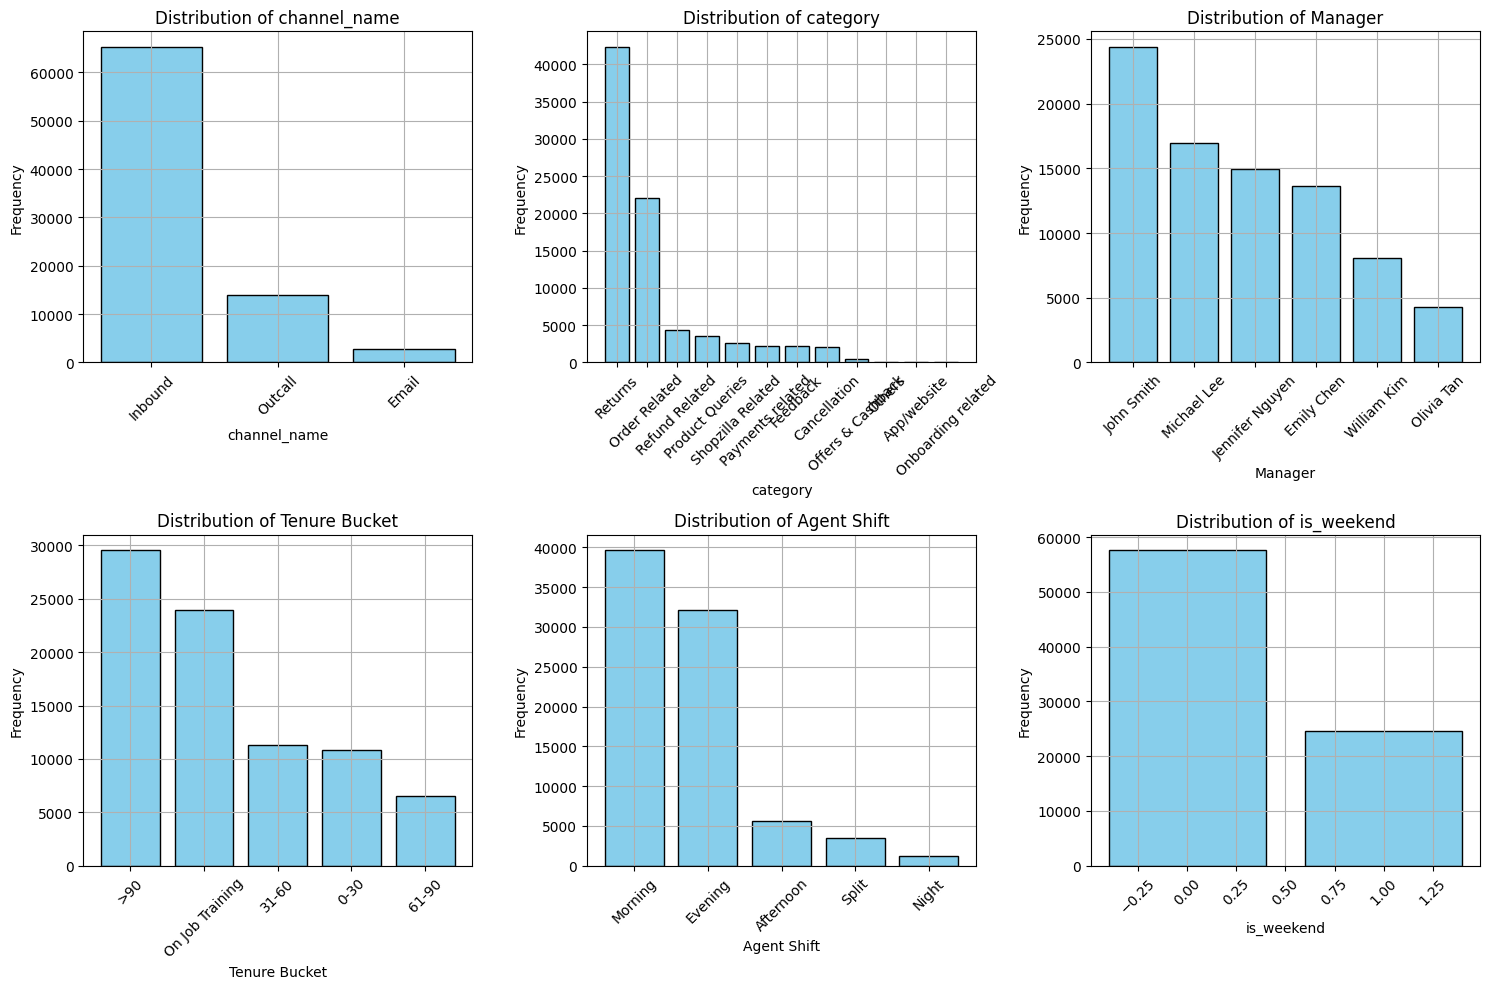

In [23]:
# Visualising distribution across different categorical variables

cat_features = ['channel_name', 'category', 'Manager', 'Tenure Bucket', 'Agent Shift', 'is_weekend']

fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    axes[i].bar(df[feature].value_counts().index, df[feature].value_counts(), color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    # axes[i].set_yticklabels(len(df[feature].value_counts().index),rotation=45)
    axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

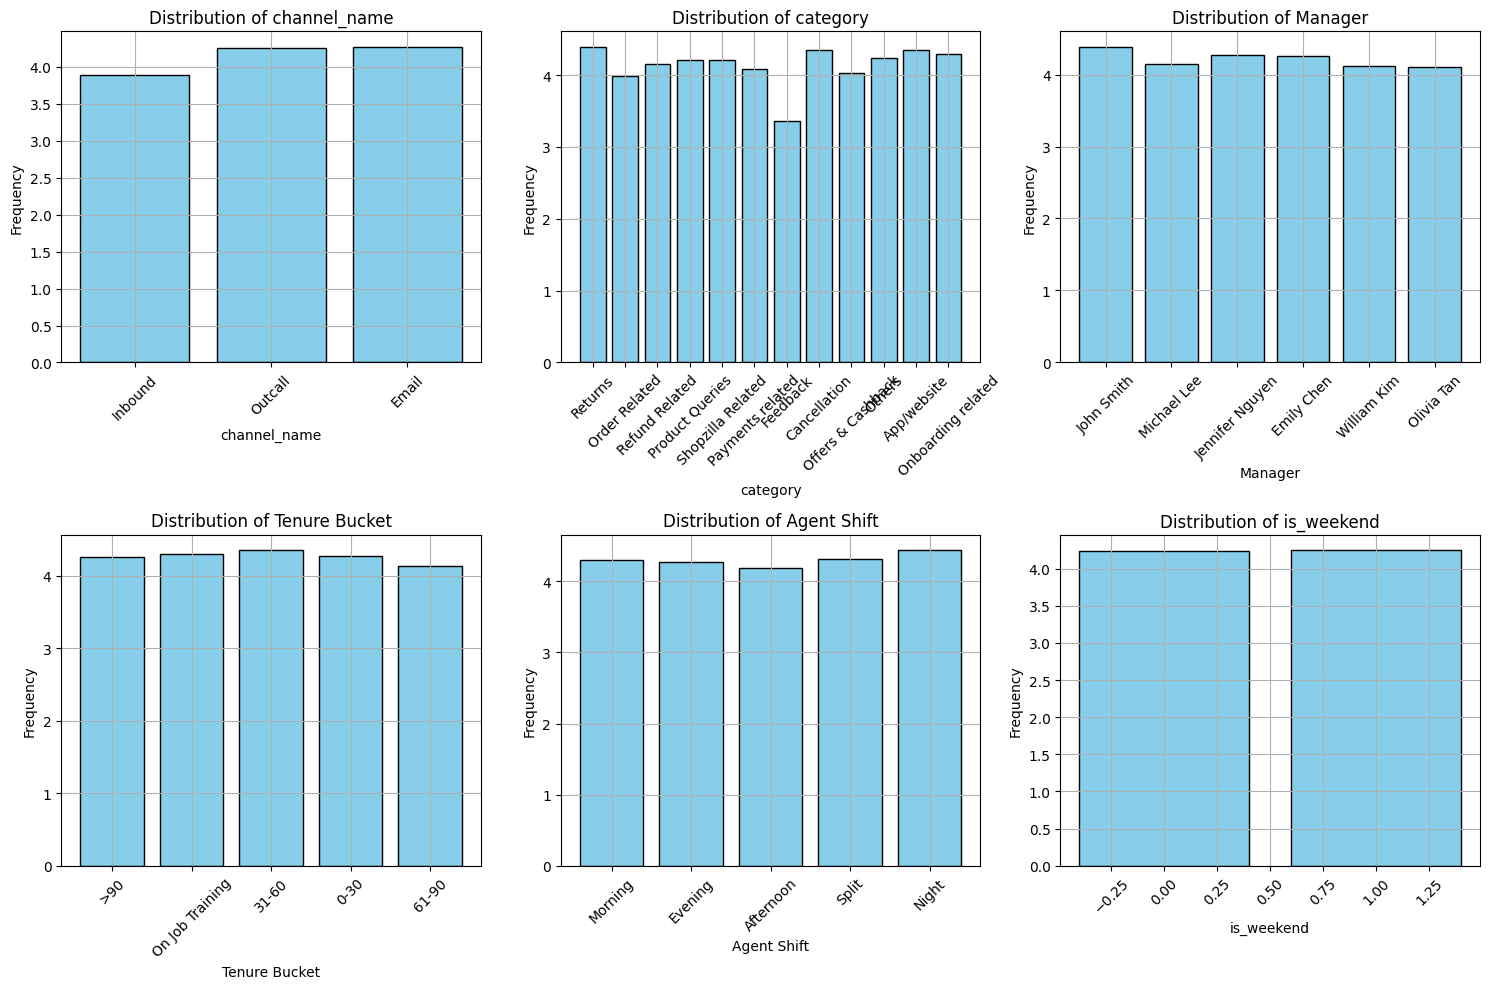

In [24]:
cat_features = ['channel_name', 'category', 'Manager', 'Tenure Bucket', 'Agent Shift', 'is_weekend']

fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(cat_features):

    median_score = df.groupby(feature)['CSAT Score'].mean()
    axes[i].bar(df[feature].value_counts().index, median_score, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

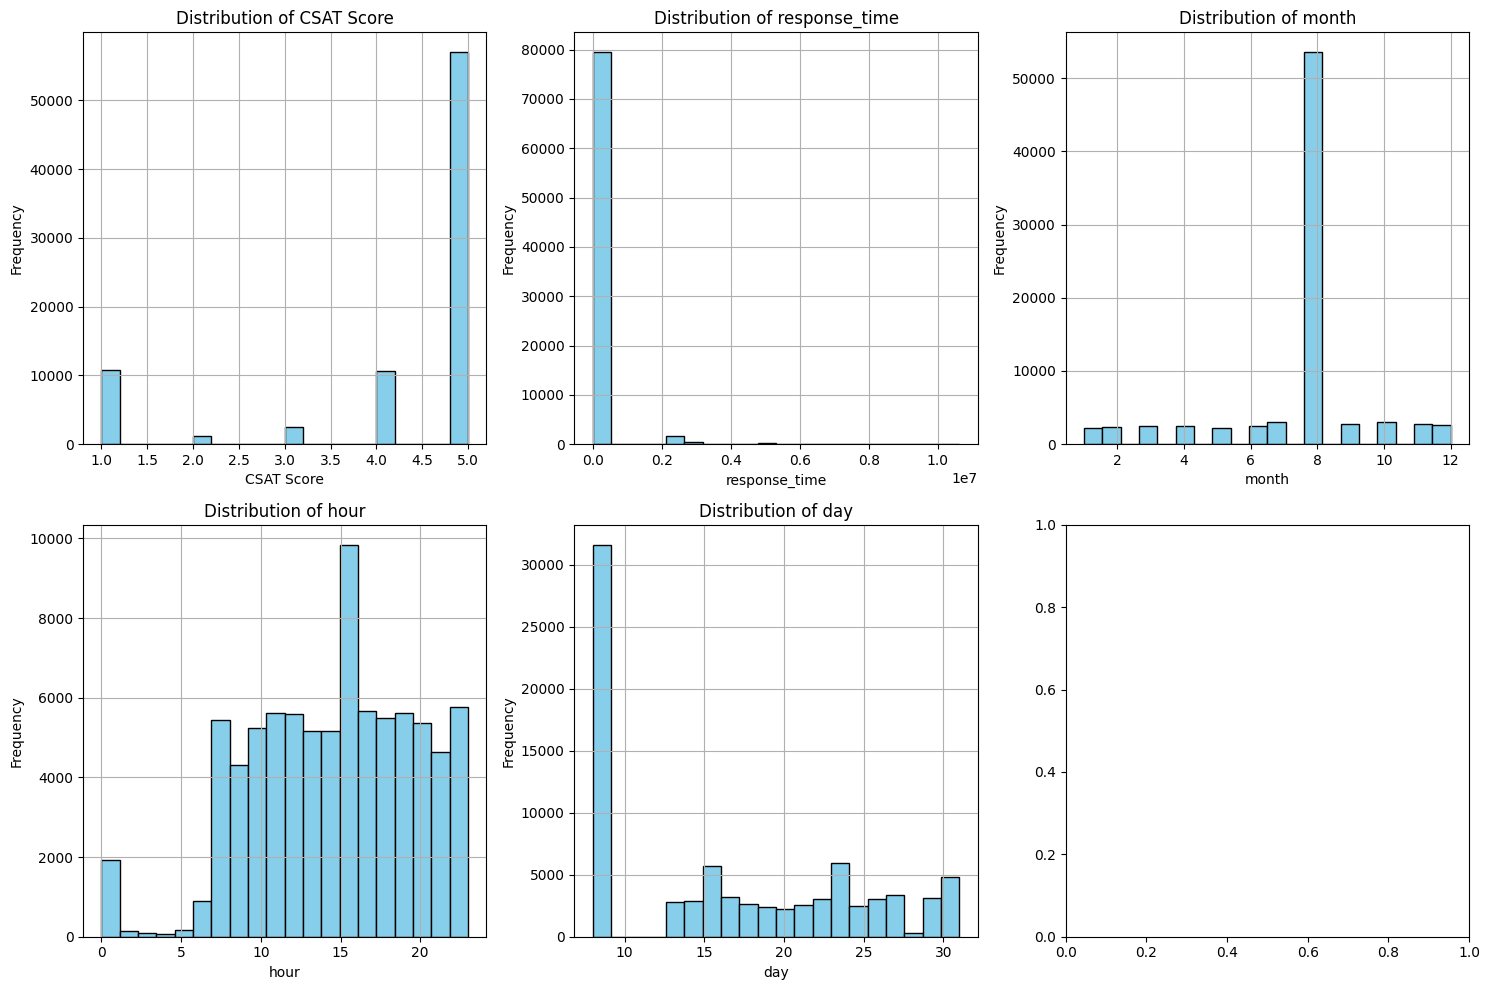

In [25]:
# visualising the distribution of numerical features

num_features = ['CSAT Score', 'response_time', 'month', 'hour','day']

# visualising the distribution of numerical features

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].hist(df[feature], bins=20, color='skyblue', edgecolor='black')


    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


There is no much variation in mean scores across various categories.

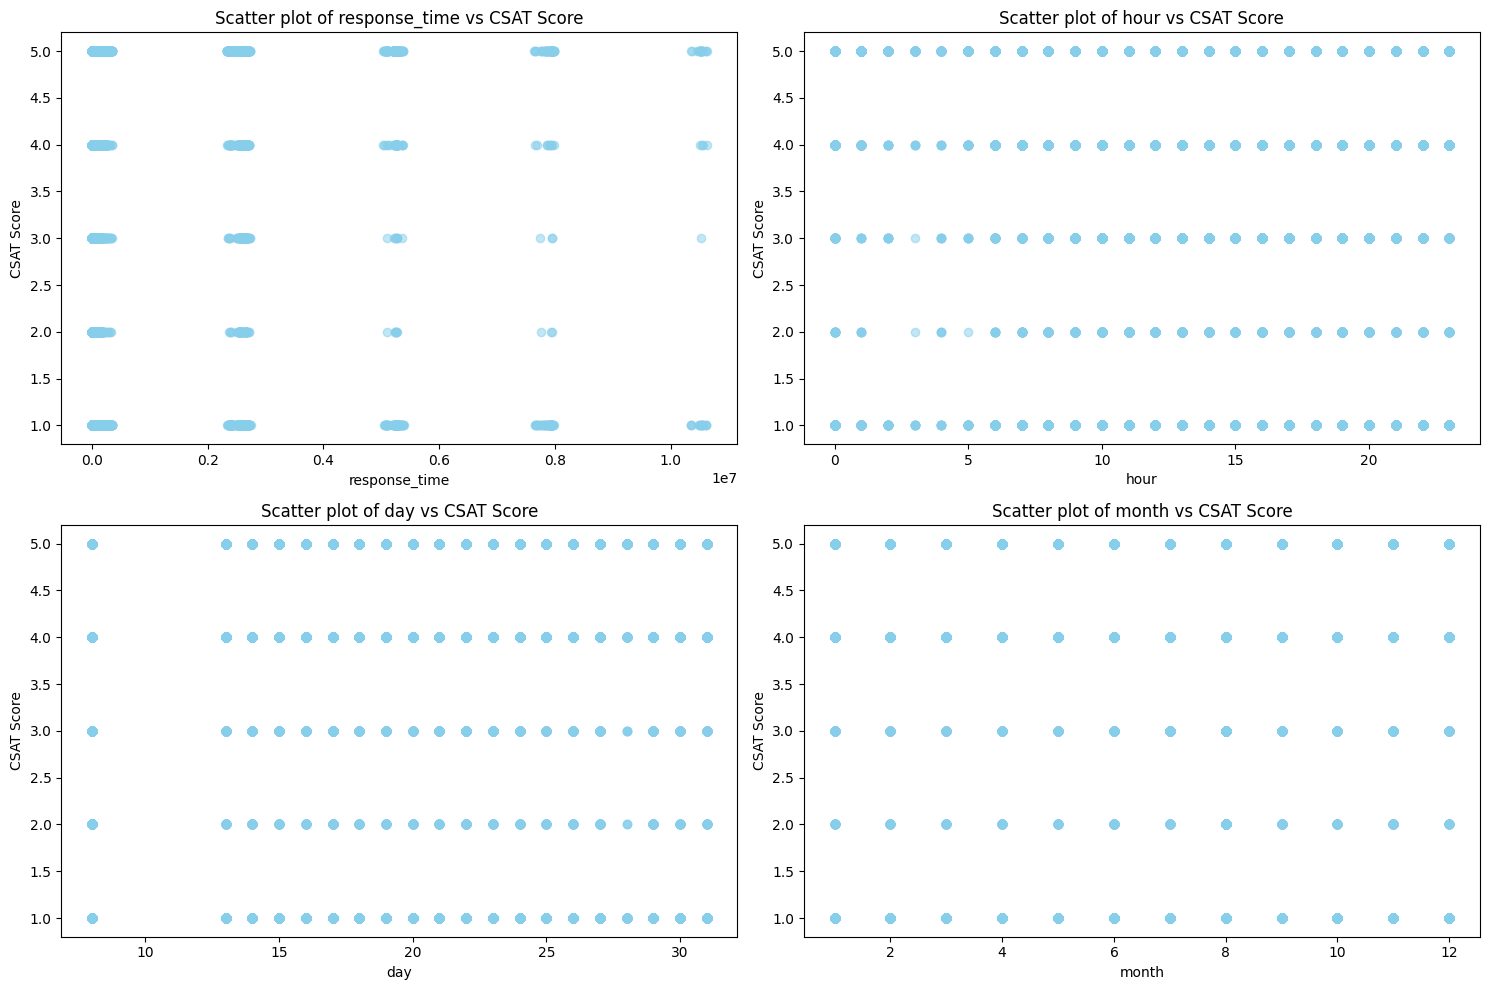

In [26]:
# sactter plots of num variables vs csat scores

num_variables = ['response_time', 'hour','day', 'month']

fig, axes = plt.subplots(2,2, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(num_variables):
    axes[i].scatter(df[feature], df['CSAT Score'], color='skyblue', alpha = 0.5)

    axes[i].set_title(f'Scatter plot of {feature} vs CSAT Score')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('CSAT Score')
    #axes[i].grid(True)


plt.tight_layout()
plt.show()

There is no clear relationship between any variables and csat score.

## ***5. Feature Engineering***

In [27]:
# cyclical encoding month, date, hour
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df['day_sin'] = np.sin(2*np.pi*df['day']/31)
df['day_cos'] = np.cos(2*np.pi*df['day']/31)
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

# Dropping month, day, hour
df.drop(columns = ['month', 'day', 'hour'], inplace = True)

# log_transforming response time
df['log_response_time'] = np.log1p(df['response_time'])+2
df.dropna(subset=['log_response_time'], inplace=True)

# Ordinal encoding tenure bucket
map = {'On Job Training':0, '0-30':1,'31-60':2, '61-90':3, '>90':4 }
df['tenure_map'] = df['Tenure Bucket'].map(map)

# map = {1:0, 2:0,3:1, 4:1, 5:2 }
# df['CSAT Score'] = df['CSAT Score'].map(map)


# Converting 'is_weekecd', CSAT score to int
df['is_weekend'] = df['is_weekend'].astype(int)
df['CSAT Score'] = df['CSAT Score'].astype(int)-1


In [28]:
# Checking for multicollinearity
num_cols = df.select_dtypes(include=np.number).columns
X = df[num_cols]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Print results
print(vif_data)

              Feature       VIF
0          CSAT Score  4.563428
1          is_weekend  1.410912
2       response_time  1.325724
3           month_sin  2.868212
4           month_cos  1.706800
5             day_sin  1.770181
6             day_cos  1.080909
7            hour_sin  1.418748
8            hour_cos  1.369672
9   log_response_time  6.421407
10         tenure_map  2.506387


As the vif scores are below 10, the features are independent and we can proceed with the model building.

In [29]:
# splitting data into train, val and test

train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['CSAT Score'])
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['CSAT Score'])


# Defining X and y
y_train = train_df['CSAT Score'].to_numpy()
y_val = val_df['CSAT Score'].to_numpy()
y_test = test_df['CSAT Score'].to_numpy()

X_train = train_df.drop(columns = ['CSAT Score'])
X_val = val_df.drop(columns = ['CSAT Score'])
X_test = test_df.drop(columns = ['CSAT Score'])

In [30]:
# Separating out features

num_features = ['month_sin', 'month_cos','day_sin','day_cos','hour_sin','hour_cos', 'log_response_time']
few_cat_features = ['channel_name','category','Manager', 'Agent Shift', 'is_weekend','tenure_map']
large_cat_features = ['Agent_name', 'Sub-category', 'Supervisor']
text_feature = ['Customer Remarks']

In [31]:
## 1. Label encoding all categorical features
le = LabelEncoder()

# Create empty DataFrames to store encoded columns
le_train = pd.DataFrame(index=X_train.index)
le_val = pd.DataFrame(index=X_val.index)
le_test = pd.DataFrame(index=X_test.index)

label_encoders = {}  # Dictionary to store LabelEncoders for each column

# Path for saving encoders
path = '/content/drive/MyDrive/Data science/Deep_learning_CSAT/encoders/le'
os.makedirs(path, exist_ok=True)

for col in large_cat_features + few_cat_features:
    le = LabelEncoder()

    # Fit the LabelEncoder on training data
    le.fit(X_train[col])

    # Save the encoder for future use
    label_encoders[col] = le

    joblib.dump(le, os.path.join(path, f"{col}_label_encoder.pkl"))

    # Transform training data
    le_train[col] = le.transform(X_train[col])

    # Mapping for validation and test data
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    le_val[col] = X_val[col].map(mapping).fillna(-1).astype(int)
    le_test[col] = X_test[col].map(mapping).fillna(-1).astype(int)

## 2.  tf-idf transform for 'customer remarks'
tfidf = TfidfVectorizer(max_features=500)

# fitting the transformer on train data
tfidf_fit = tfidf.fit(X_train['Customer Remarks'].fillna(''))

# transforming the data
tfidf_train = tfidf.transform(X_train['Customer Remarks'].fillna(''))
tfidf_val = tfidf.transform(X_val['Customer Remarks'].fillna(''))
tfidf_test = tfidf.transform(X_test['Customer Remarks'].fillna(''))

# Saving the fit
path = '/content/drive/MyDrive/Data science/Deep_learning_CSAT/encoders'
joblib.dump(tfidf_fit, os.path.join(path, 'tfidf_encoder.pkl'))

# Convert to df
tfidf_train_df = pd.DataFrame(tfidf_train.toarray(), columns=tfidf.get_feature_names_out(),index=X_train.index)
tfidf_val_df = pd.DataFrame(tfidf_val.toarray(), columns=tfidf.get_feature_names_out(), index=X_val.index)
tfidf_test_df = pd.DataFrame(tfidf_test.toarray(), columns=tfidf.get_feature_names_out(), index=X_test.index)


## 3. Joining all features

X_train_new = pd.concat([X_train[num_features], le_train, tfidf_train_df], axis=1)
X_val_new = pd.concat([X_val[num_features], le_val, tfidf_val_df], axis=1)
X_test_new = pd.concat([X_test[num_features], le_test, tfidf_test_df], axis=1)

# checking for nan
X_val_new.isna().sum()

,0
month_sin,0
month_cos,0
day_sin,0
day_cos,0
hour_sin,0
...,...
wrong,0
yes,0
yet,0
you,0


We saw in EDA that the data is highly imbalanced. So we use SMOTENC to oversample the minority classes.

In [32]:
# Oversampling under represented classes
cat_indices = list(range(7, 16))

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_train_new, y_train)

train_df_resampled = pd.concat([X_resampled, pd.Series(y_resampled, name='CSAT Score')], axis=1)

Transforming the features

In [33]:
## 1.  new tfidf encoded train data
tf_idf_train_final = X_resampled.iloc[:,16:517]

## 2. new OH encoded categorical data
# fit
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(train_df_resampled[few_cat_features])
# tranform
oh_train = ohe.transform(X_resampled[few_cat_features])
oh_val = ohe.transform(X_val_new[few_cat_features])
oh_test = ohe.transform(X_test_new[few_cat_features])
# save the fit
path = '/content/drive/MyDrive/Data science/Deep_learning_CSAT/encoders'
joblib.dump(ohe, os.path.join(path, 'ohe_encoder.pkl'))
# Converting back to Dataframes

oh_train_df = pd.DataFrame(oh_train.toarray(), index=train_df_resampled.index)
oh_val_df = pd.DataFrame(oh_val.toarray(), index=X_val_new.index)
oh_test_df = pd.DataFrame(oh_test.toarray(), index=X_test_new.index)

## 3. New scaled numeric feature
# fit
scaler = StandardScaler()
scaler_fit = scaler.fit(train_df_resampled[['log_response_time']])
# transform
response_time_train = scaler.transform(train_df_resampled[['log_response_time']])
response_time_val = scaler.transform(X_val_new[['log_response_time']])
response_time_test = scaler.transform(X_test_new[['log_response_time']])
# save the scaler
joblib.dump(scaler_fit, os.path.join(path, 'standard_scaler.pkl'))
# Converting back to Dataframes
response_time_train_df = pd.DataFrame(response_time_train,columns=['log_response_time'],index=train_df_resampled.index)
response_time_val_df = pd.DataFrame(response_time_val,columns=['log_response_time'],index=X_val_new.index)
response_time_test_df = pd.DataFrame(response_time_test,columns=['log_response_time'],index=X_test_new.index)


We can now add the one hot encoded features and scaled features to the old numeric features

In [34]:
# combining all numeric features

old_num_features = ['month_sin', 'month_cos','day_sin','day_cos','hour_sin','hour_cos']

# concatenating the new encodedfeatures
num_train_final = pd.concat([train_df_resampled[old_num_features],oh_train_df, response_time_train_df], axis=1)
num_val = pd.concat([X_val_new[old_num_features],oh_val_df,response_time_val_df], axis=1)
num_test = pd.concat([X_test_new[old_num_features],oh_test_df,response_time_test_df], axis=1)

In [35]:
# Extracting data of large_cat_features for embedding

supervisor_ids_train = train_df_resampled['Supervisor']
agent_ids_train = train_df_resampled['Agent_name']
subcategory_ids_train =train_df_resampled['Sub-category']

supervisor_ids_test = X_test_new['Supervisor']
agent_ids_test = X_test_new['Agent_name']
subcategory_ids_test = X_test_new['Sub-category']

supervisor_ids_val = X_val_new['Supervisor']
agent_ids_val = X_val_new['Agent_name']
subcategory_ids_val = X_val_new['Sub-category']

agent_len = df['Agent_name'].nunique()
supervisor_len = df['Supervisor'].nunique()
subcategory_len = df['Sub-category'].nunique()

## ***6. Model building***

In [36]:
# Defining inputs of keras model

# inputs for embedding
agent_input = Input(shape=(1,))
supervisor_input = Input(shape=(1,))
subcategory_input = Input(shape=(1,))

# numeric inputs
numeric_input = Input(shape=(num_train_final.shape[1],))

# tf-idf input
tfidf_input = Input(shape=(tf_idf_train_final.shape[1],))

In [37]:
# Defining the embedding layers

agent_emb = Embedding(input_dim = agent_len, output_dim=25)(agent_input)
supervisor_emb = Embedding(input_dim = supervisor_len, output_dim=4)(supervisor_input)
subcategory_emb = Embedding(input_dim = subcategory_len, output_dim=4)(subcategory_input)

agent_emb = Flatten()(agent_emb)
supervisor_emb = Flatten()(supervisor_emb)
subcat_emb = Flatten()(subcategory_emb)

agent_subcat = Concatenate()([agent_emb, subcat_emb])
agent_supervisor = Concatenate()([agent_emb, supervisor_emb])


In [38]:
# combined input
from keras.callbacks import EarlyStopping
combined = Concatenate()([agent_subcat,agent_supervisor,
                          #agent_emb, supervisor_emb, subcat_emb,
                          numeric_input, tfidf_input
                          ])

# Defining layers
x = Dense(64, kernel_regularizer=l2(0.005))(combined)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.4)(x)
x = Dense(32, kernel_regularizer=l2(0.005))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)
x = Dense(16, kernel_regularizer=l2(0.005))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
# x = Dense(16, kernel_regularizer=l2(0.005))(x)
# x = BatchNormalization()(x)
# x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.1)(x)

# output layer
output = Dense(5, activation='softmax')(x)
#output = Dense(1, activation='relu')(x)


# optimizer
optimizer = Adam(learning_rate=0.0005)

# defining the model
model = Model(inputs=[agent_input, supervisor_input, subcategory_input,
                      numeric_input, tfidf_input],
                    outputs=output)

# compiling the model
model.compile(optimizer=optimizer, loss=SparseCategoricalFocalLoss(gamma=2), metrics=['accuracy'])
#model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
# Defining learning rate behaviour
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [39]:
#  training  the model

history = model.fit(
    x=[agent_ids_train, supervisor_ids_train, subcategory_ids_train,
       num_train_final.to_numpy(),tf_idf_train_final.to_numpy()
    ],
    y=y_resampled,
    validation_data=([agent_ids_val, supervisor_ids_val,subcategory_ids_val,
                      num_val.to_numpy(), tfidf_val_df.to_numpy()
    ],
    y_val),

    epochs=50,
    batch_size=32,
    callbacks=[reduce_lr, early_stop]

)



Epoch 1/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 50s 8ms/step - accuracy: 0.3319 - loss: 1.2583 - val_accuracy: 0.4424 - val_loss: 0.8231 - learning_rate: 5.0000e-04
Epoch 2/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 0.4999 - loss: 0.7332 - val_accuracy: 0.4191 - val_loss: 0.8723 - learning_rate: 5.0000e-04
Epoch 3/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.5293 - loss: 0.6730 - val_accuracy: 0.4723 - val_loss: 0.7878 - learning_rate: 5.0000e-04
Epoch 4/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 81s 8ms/step - accuracy: 0.5430 - loss: 0.6407 - val_accuracy: 0.4343 - val_loss: 0.8113 - learning_rate: 5.0000e-04
Epoch 5/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - accuracy: 0.5607 - loss: 0.6119 - val_accuracy: 0.5262 - val_loss: 0.7480 - learning_rate: 5.0000e-04
Epoch 6/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.5690 - loss: 0.5955 - val_accuracy: 0.5363 - val_loss: 0.7447 - learning_rate: 5.0000e-04
Epoch 7/50
5705/5705 ━━━━━━━━━━━━━━━━━━━━ 90s 

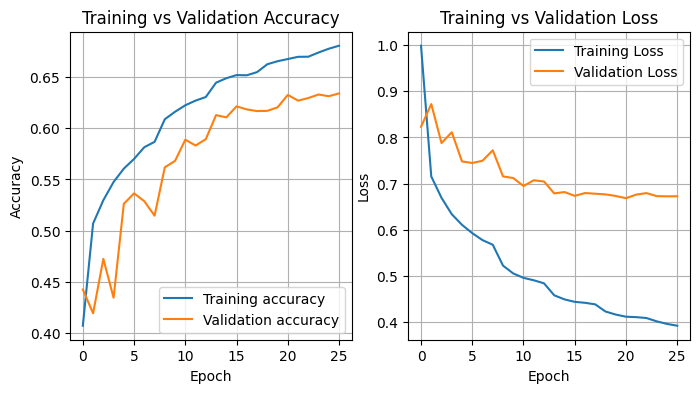

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))



# Plot training & validation accuracy values

axs[0].plot(history.history['accuracy'], label='Training accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training vs Validation Accuracy')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training vs Validation Loss')
axs[1].legend()
axs[1].grid(True)


plt.show()

## ***7. Evaluation, Saving the model and sanity check with test data***

Defining evaluation metrics

In [43]:
# Predicting CSAT scores of test data
test_data=([agent_ids_test, supervisor_ids_test,subcategory_ids_test, num_test.to_numpy(), tfidf_test.toarray()
    ])
y_pred = model.predict(test_data)
#y_pred_rounded = np.clip(np.round(y_pred), 1, 5)

# finding out the class with max probability value
y_predict_class = np.argmax(y_pred, axis=1)

514/514 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


In [44]:
def metrics(y_test,y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='weighted')
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  cm = confusion_matrix(y_test, y_pred)
  #print(cm)

  print(f"Accuracy: {accuracy}")
  print(f"F1 Score: {f1}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")

  # plot confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')

  return

Accuracy: 0.6270835868110476
F1 Score: 0.6046143597402486
Precision: 0.6067985667443624
Recall: 0.6270835868110476


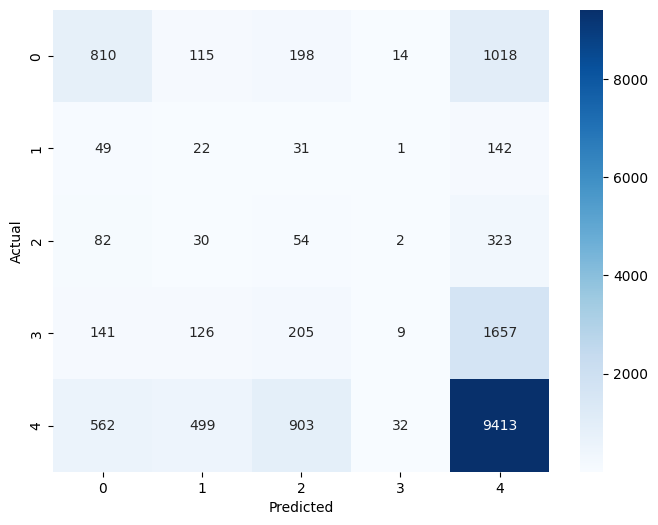

In [47]:
metrics(y_test, y_predict_class)

We obtaain an accuracy and other parameters of about 0.62. Comparing with the baseline of random allocation where accuracy would be 0.2(5 classes), and the unclear distinction btween classes as seen in EDA, we consider this to be a good accuracy and save the model.

In [48]:
# Save the model
keras.saving.save_model(model, os.path.join(path, 'nn_model.keras'))

# reloading the model
model1 = load_model(os.path.join(path, 'nn_model.keras'))

In [ ]:
y_predict = model1.predict(test_data)

# finding out the class with max probability value
y_predict_class = np.argmax(y_predict, axis=1) +1

metrics(y_test, y_predict_class)

## ***8. Conclusion***

This project aimed to build a deep learning model to predict customer satisfaction ratings (CSAT) based on structured features. The workflow covered the full machine learning pipeline — from data preprocessing to advanced model tuning and performance evaluation.

Throughout the project, several critical tasks were accomplished:

**Data Preparation:** The dataset was thoroughly cleaned and preprocessed. Categorical variables were encoded, numerical features were scaled, and data imbalance was addressed using SMOTEENC, which is particularly suitable when working with categorical features.

**Model Development:** A deep neural network was constructed using Keras, with efforts to optimize the architecture through careful selection of layers, activations, dropout, and batch normalization. The model used focal loss to mitigate the impact of class imbalance during training.

**Training and Evaluation:** The training and validation loss curves were analyzed over multiple experiments to monitor overfitting and generalization. Metrics such as accuracy, precision, recall, and F1-score were computed for each class, offering insight into per-class performance.

**Class Imbalance and Alternatives:** The dataset exhibited a highly imbalanced class distribution, leading to strong prediction performance for the dominant class but poor results for minority classes. Strategies such as class merging and the consideration of regression over classification were explored to improve robustness and interpretability.

**Modeling Alternatives:** Regression was proposed as a viable alternative given the ordinal nature of CSAT ratings. A Keras regression model was also prototyped with a single-node output layer and Mean Squared Error (MSE) loss to assess whether treating CSAT as a continuous variable yields better generalization.

**Interpretation and Next Steps:** The project highlighted the need to tailor both the model and the loss function to the structure of the target variable. Exploring ordinal regression, custom loss functions, and more expressive models (like attention-based architectures) may enhance performance. Additionally, collecting more data or improving feature engineering could support better prediction of underrepresented classes.

In summary, this project demonstrates application of deep learning to customer satisfaction prediction.





